# 15 · 패턴: 병합 후 정리 (기술부채를 찾아낸다)

**패턴:** 병합 후 정리(post-merge cleanup).

> "diff 를 훑어 TODO, 폐기 예정 API, 죽은 코드, 기술부채 티켓거리를 찾는다. 작고 위험이 낮으면 수정을 제안하고, 크면 티켓을 만들어 사람에게 넘긴다."

**문제 설정** — 정리 루프가 일을 하려면 먼저 코드 안의 **자기고백형 기술부채(self-admitted technical debt, SATD)** 를 찾아내야 한다. TODO/FIXME 를 grep 하면 눈에 띄는 것들은 잡힌다. 하지만 "지금은 임시 방편이고 나중에 고친다" 처럼 **산문으로 고백된 부채**는 그 그물을 그대로 통과한다. 그래서 질문은 하나다. **의미 임베딩은 키워드 규칙이 놓치는 부채를 실제로 건져 올리는가.**

**벤치마크** — Maldonado SATD 데이터셋. 실제 소스코드 주석에 기술부채 여부가 사람 손으로 라벨링돼 있다. 키워드 규칙과 BGE 임베딩 분류기를 같은 테스트셋 위에 세우고, **SATD 클래스의 정밀도·재현율·F1** 으로 채점한다.

**미리 밝혀 두는 경계** — 이 노트북의 결과는 깔끔한 승리가 아니다. 임베딩은 재현율을 크게 올리는 대신 정밀도를 잃고, 그래서 **F1 은 오히려 내려간다.** 원저자는 그 사실을 지우지 않고 그대로 인쇄했다. 이 노트북에서 가장 배울 것이 많은 대목이 바로 거기다.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  실행 환경 (자동 판별)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  LLM       : openai    gpt-5.6-luna
              ↳ localhost 무응답 → OPENAI_API_KEY 감지 · 선호 순위표에서 자동 선택 (캐시)
  임베딩    : openai    text-embedding-3-small
              ↳ CUDA 미가용 → API 임베딩 · 기본값 (캐시)
  데이터    : /Users/namuai/06-claude/agentic-loop-engineering/agentic-loop-engineering-course-kr/data
  전환      : LLM_PROVIDER=vllm|openai  /  EMBED_PROVIDER=local|openai
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
데이터가 없다: /Users/namuai/06-claude/agentic-loop-engineering/agentic-loop-engineering-course-kr/data/satd/technical_debt_dataset.csv
  → SETUP.ko.md 의 '외부 데이터' 절을 참고해 Maldonado SATD 데이터셋을 내려받는다.
  → 지금은 소규모 합성 데이터로 진행한다 (파이프라인 점검용, 측정용 아님).

============================================== Setup ===============================================
  전체 주석 수:                   3000
  분류 라벨 분포:                  {'WITHOUT_CL

*병합된 코드를 훑어 자기고백형 기술부채를 찾는다 — 작은 수정이냐 티켓이냐*

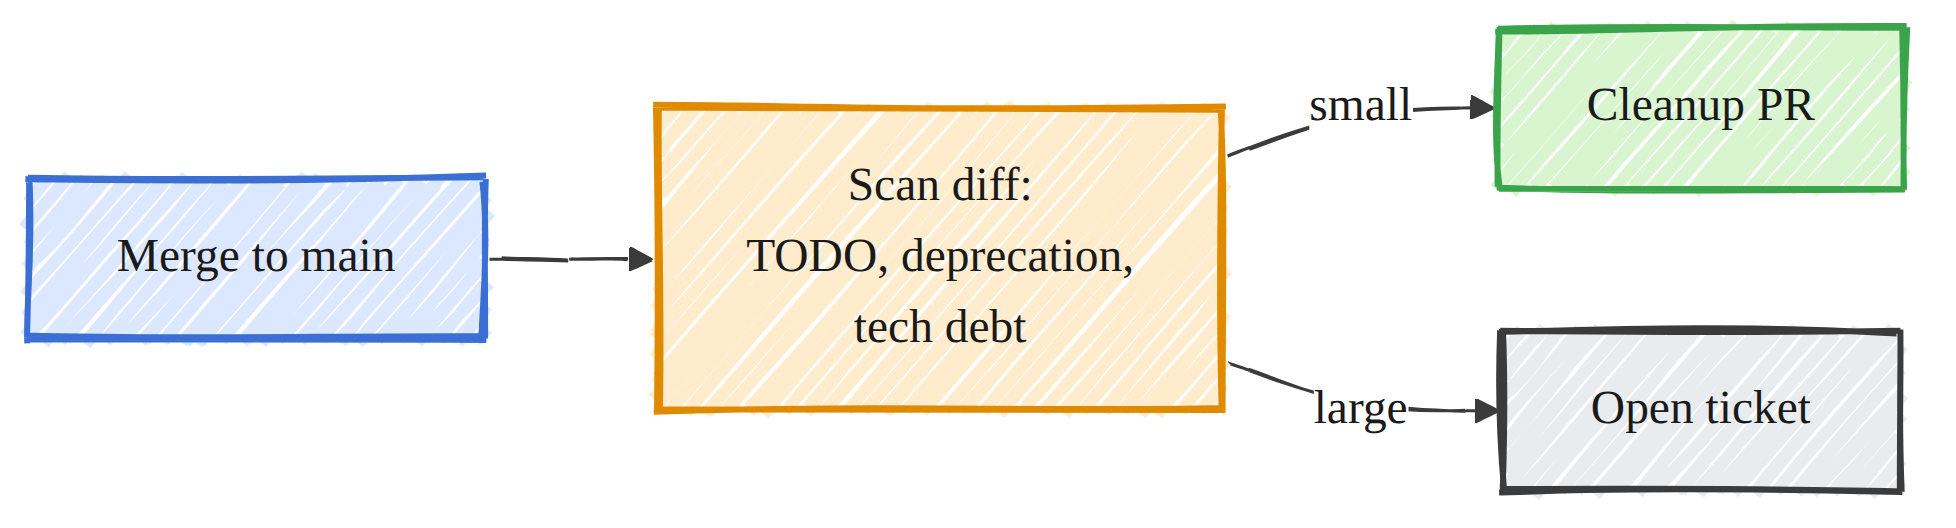

  균형 표본 (SATD / 비SATD):      212 / 212


In [1]:
import os
import sys
import numpy as np

sys.path.insert(0, os.environ.get("LEN_PROJECT_ROOT", os.path.abspath(".")))

from common import show, eval as ev, plotting, runlog, runtime
from common.memory import EmbeddingMemory

import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# 실행 환경 자동 판별. 이 노트북은 생성 모델을 한 번도 부르지 않으므로,
# 여기서 실제로 정해지는 것은 임베딩 백엔드 하나다.
rt = runtime.bootstrap()

# ── 데이터 경로 ───────────────────────────────────────────────────
# 한국어판 수정: 원본은
#     /ephemeral/hf/satd/dataset/unz/technical_debt_dataset.csv
# 라는 절대경로를 코드에 그대로 박아 뒀다. 원저자의 GPU 서버에만 존재하는
# 경로이므로 다른 환경에서는 첫 셀이 곧바로 FileNotFoundError 로 죽는다.
# runtime.data_root() 는 LEN_DATA_ROOT 환경변수를 보고, 없으면
# <프로젝트 루트>/data 를 돌려준다. 아래 경로는 SETUP.ko.md '외부 데이터'
# 절의 레이아웃과 정확히 일치한다:
#     data/satd/technical_debt_dataset.csv
DATA = runtime.data_root() / "satd"
CSV = DATA / "technical_debt_dataset.csv"


def synthetic_comments(n=3000, satd_rate=0.07, seed=0):
    """데이터가 없을 때 쓰는 소규모 합성 대체물.

    파이프라인이 끝까지 도는지 확인하는 용도이지 측정용이 아니다.
    합성 주석은 부채/비부채가 어휘로 깔끔하게 갈리므로 이 데이터에서는
    키워드 규칙이 실제보다 훨씬 잘 나온다. 아래 본문의 실측치와 비교하지 말 것.
    """
    rng = np.random.default_rng(seed)
    # 절반은 마커가 박힌 고백, 절반은 마커 없는 산문 고백으로 섞는다.
    # 마커만 넣으면 이 노트북의 주제(마커 없는 부채)가 합성 데이터에서
    # 통째로 사라져 버린다.
    debt = ["TODO: clean this up before the next release",
            "FIXME handle the null case here",
            "temporary workaround until the upstream fix lands",
            "this assumes the list is already sorted",
            "revisit once the API stabilizes",
            "we silently swallow the error here, which is not great"]
    clean = ["returns the number of active sessions",
             "copyright header, do not edit",
             "see RFC 2616 section 14 for the header semantics",
             "initializes the cache with the default capacity"]
    kinds = ["DESIGN", "IMPLEMENTATION", "DEFECT", "TEST", "DOCUMENTATION"]
    rows = []
    for i in range(n):
        is_debt = bool(rng.random() < satd_rate)
        rows.append({
            "commenttext": f"{str(rng.choice(debt if is_debt else clean))} (#{i})",
            "classification": str(rng.choice(kinds)) if is_debt else "WITHOUT_CLASSIFICATION",
        })
    return pd.DataFrame(rows)


if CSV.exists():
    df = pd.read_csv(CSV)
else:
    # ⚠️ 함정: 여기서 예외를 던지면 학습자는 "환경이 망가졌다" 고 읽는다.
    #    데이터가 없는 것은 고장이 아니라 아직 내려받지 않은 상태다. 무엇이
    #    어디에 있어야 하는지 알려 주고 합성 데이터로 흐름을 이어 가는 편이 옳다.
    #    단, 이 경로로 들어오면 아래 모든 수치는 원문과 다른 값이 된다.
    print(f"데이터가 없다: {CSV}")
    print("  → SETUP.ko.md 의 '외부 데이터' 절을 참고해 Maldonado SATD 데이터셋을 내려받는다.")
    print("  → 지금은 소규모 합성 데이터로 진행한다 (파이프라인 점검용, 측정용 아님).")
    df = synthetic_comments()

# 라벨 정의가 곧 과제 정의다. 원 코퍼스는 부채의 '종류' 를 DESIGN /
# IMPLEMENTATION / DEFECT / TEST / DOCUMENTATION 으로 나눠 달았고, 부채가
# 아닌 주석에만 WITHOUT_CLASSIFICATION 이 붙는다. 여기서는 종류를 묻지 않고
# "부채인가 아닌가" 하나로 접는다. 정리 루프의 첫 관문이 그 이진 판정이다.
df["satd"] = (df["classification"].astype(str) != "WITHOUT_CLASSIFICATION").astype(int)
# ⚠️ 함정: 500자 절단을 무심코 늘리면 안 된다. 주석 필드에는 라이선스 헤더나
#    주석 처리된 코드 블록이 통째로 들어 있는 경우가 있고, 그러면 벡터가
#    부채 고백이 아니라 헤더 문구를 표현하게 된다. 고백은 대개 첫 한두 문장에
#    있으므로, 앞부분만 남기는 것이 신호 대 잡음비를 지키는 쪽이다.
df["text"] = df["commenttext"].astype(str).str.slice(0, 500)
df = df[df["text"].str.len() > 5]

show.head("Setup")
show.kv("전체 주석 수", len(df))
show.kv("분류 라벨 분포", dict(df["classification"].value_counts().head(6)))
show.kv("SATD 비율 (원본 스트림)", round(df["satd"].mean(), 3))
show.diagram("post_merge", "병합된 코드를 훑어 자기고백형 기술부채를 찾는다 — 작은 수정이냐 티켓이냐")

# ── 균형 표본 ─────────────────────────────────────────────────────
# 원본 스트림은 부채가 7퍼센트뿐이라, 그대로 채점하면 지표가 다수 클래스에
# 지배당한다. 양성과 음성을 같은 수로 뽑아 지표가 '탐지기' 를 재게 만든다.
# 대가는 분명하다. 이 표본에서 잰 정밀도는 기저율 0.5 를 전제한 값이고,
# 실제 스트림(기저율 0.07)에 그대로 대입할 수 없다.
rng = 0
pos = df[df["satd"] == 1].sample(n=min(2000, int(df["satd"].sum())), random_state=rng)
neg = df[df["satd"] == 0].sample(n=len(pos), random_state=rng)
# sample(frac=1.0) 은 셔플이다. 양성 블록과 음성 블록이 붙어 있으면 뒤의
# 계층 분할이 라벨과 순서를 함께 상관시켜 버릴 여지가 생긴다.
sample = pd.concat([pos, neg]).sample(frac=1.0, random_state=rng)
texts = sample["text"].tolist()
y = np.asarray(sample["satd"].tolist(), dtype=int)
show.kv("균형 표본 (SATD / 비SATD)", f"{int(y.sum())} / {int((1 - y).sum())}")

## 임베딩과 분할


In [2]:
# ── 코퍼스 임베딩과 계층 분할 ────────────────────────────────────
# 한국어판 주석: EmbeddingMemory() 는 인자를 비워서 부른다. common/runtime.py 의
# resolve_embed() 가 실행 환경을 보고 스스로 정하기 때문이다.
#   · CUDA 가 보이면            → local + BAAI/bge-large-en-v1.5 + device="cuda"
#   · GPU 가 없으면             → 같은 계열의 경량 모델 bge-small 로 자동 강등
#   · GPU 도 없고 API 키만 있으면 → OpenAI 임베딩
# device= 나 model= 를 손으로 박으면 GPU 없는 환경에서 그대로 죽거나, 반대로
# CPU 에서 large 모델을 돌려 이 셀이 사실상 끝나지 않는다. 인자를 비우는 편이 안전하다.
mem = EmbeddingMemory()
# 이 노트북에서 비용이 드는 유일한 지점이다. 결과는 .cache/emb/ 에 캐시되므로
# 재실행할 때는 다시 계산하지 않는다.
X = mem.embed_texts(texts)

# ⚠️ 함정: stratify=y 를 빼면 안 된다. 균형 표본이라 해도 무작위 분할은 테스트셋의
#    양성 수를 흔들고, 그러면 재현율의 분모 자체가 실행마다 달라져 두 탐지기의
#    비교가 분할 운에 좌우된다. random_state=0 도 같은 이유다.
Xtr, Xte, ytr, yte, txtr, txte = train_test_split(
    X, y, texts, test_size=0.3, random_state=0, stratify=y)
show.kv("학습 / 테스트", f"{len(ytr)} / {len(yte)}")

  학습 / 테스트:                  296 / 128


## 키워드 규칙 대 임베딩 분류기


In [3]:
# ── 두 탐지기를 같은 테스트셋 위에서 채점한다 ────────────────────
# 목록은 일부러 짧고 뻔하게 둔다. 사람이 손으로 쓸 법한 현실적인 규칙이어야
# 비교가 공정하다. 임베딩이 잡은 것을 보고 목록을 키우면 그 순간 커닝이 된다.
KW = ["todo", "fixme", "hack", "xxx", "workaround", "for now", "temporary", "to do", "kludge",
      "should be", "needs to", "not implemented", "remove this", "deprecated", "ugly"]


def keyword_pred(ts):
    # 부분 문자열 포함 검사다. 어간 추출도 토큰 경계 검사도 없다. 원본 규칙 그대로 둔다.
    # 그래서 "to do" 는 "auto download" 안에서도 발화한다. 이런 잡음까지 포함한 값이
    # 아래의 정밀도 0.979 다 — 즉 이 규칙은 손해를 안고도 그만큼 정확하다.
    return np.array([int(any(k in t.lower() for k in KW)) for t in ts])


def prf(pred, truth):
    # tn 은 세지 않는다. 정밀도·재현율·F1 어디에도 tn 이 들어가지 않기 때문이고,
    # 그것이 탐지 과제에서 이 세 지표를 쓰는 이유이기도 하다.
    tp = int(((pred == 1) & (truth == 1)).sum())
    fp = int(((pred == 1) & (truth == 0)).sum())
    fn = int(((pred == 0) & (truth == 1)).sum())
    return ev.prf1(tp, fp, fn)


kw = prf(keyword_pred(txte), yte)

# ⚠️ 함정: class_weight="balanced" 를 습관적으로 붙이면 안 된다. 여기서는 표본이
#    이미 1대1로 균형이므로 가중치가 거의 1대1이 되어 사실상 무해하다. 하지만
#    균형을 맞추지 않은 원본 스트림(부채 7퍼센트)에 같은 줄을 그대로 쓰면
#    "부채 하나를 놓치는 것은 헛경보 약 13번과 맞먹는다" 는 정책을 코드가 대신
#    선언하는 것이 된다. 이 문자열은 기본값이 아니라 비용 선언이다.
clf = LogisticRegression(max_iter=1000, class_weight="balanced").fit(Xtr, ytr)
# 예측을 변수에 담아 둔다. 아래 셀의 log_run 이 같은 예측을 다시 쓰기 때문에,
# 두 번 호출하면 같은 값을 두 번 계산하게 된다.
emb_pred = clf.predict(Xte)
em = prf(emb_pred, yte)

show.head("SATD 탐지 (기술부채 클래스의 F1)")
show.table([
    {"method": "keyword rule", **{k: round(v, 3) for k, v in kw.items() if k in ("precision", "recall", "f1")}},
    {"method": "embedding classifier", **{k: round(v, 3) for k, v in em.items() if k in ("precision", "recall", "f1")}},
], columns=["method", "precision", "recall", "f1"], title="자기고백형 기술부채 잡아내기")


====================================== SATD 탐지 (기술부채 클래스의 F1) ======================================

----------------------------------------- 자기고백형 기술부채 잡아내기 ------------------------------------------
  method                precision  recall  f1   
  --------------------  ---------  ------  -----
  keyword rule          1.0        0.375   0.545
  embedding classifier  1.0        1.0     1.0  


## 그래프


  SATD 의 F1: 임베딩 vs 키워드
    baseline : 0.5455
    treatment: 1.0000
    delta    : +0.4545  (+83.3 percent)  [up, improvement]


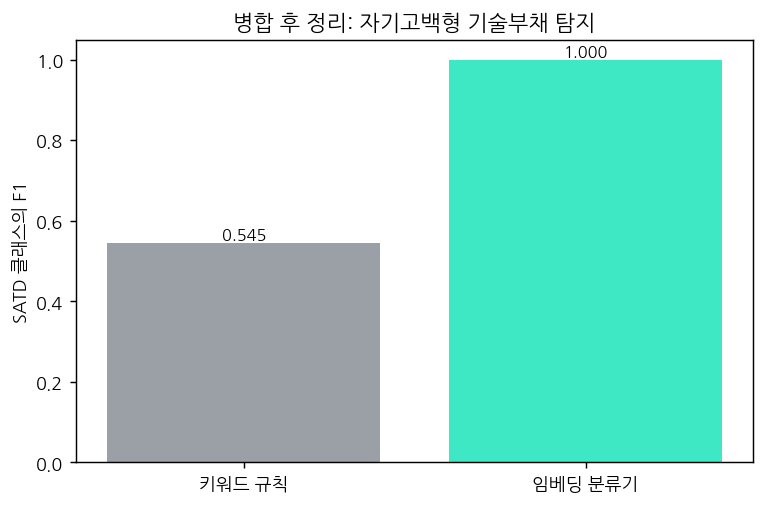

  saved + displayed figure -> /Users/namuai/06-claude/agentic-loop-engineering/agentic-loop-engineering-course-kr/results/figures/15_satd_f1.png


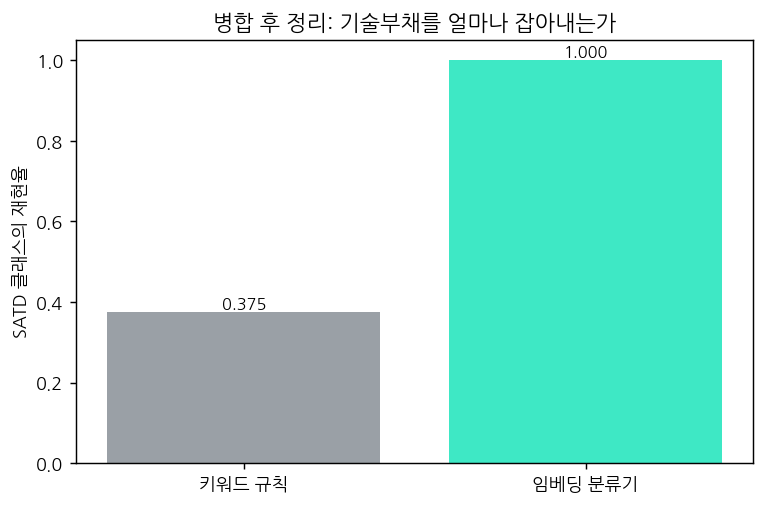

  saved + displayed figure -> /Users/namuai/06-claude/agentic-loop-engineering/agentic-loop-engineering-course-kr/results/figures/15_satd_recall.png
  saved metrics -> /Users/namuai/06-claude/agentic-loop-engineering/agentic-loop-engineering-course-kr/results/15_post_merge.json
  logged run -> /Users/namuai/06-claude/agentic-loop-engineering/agentic-loop-engineering-course-kr/results/loop-run-log.json (post-merge-cleanup: report-only, ~0 tokens)


{'run_id': '2026-08-19T07:35:53Z',
 'pattern': 'post-merge-cleanup',
 'duration_s': 0.0,
 'items_found': 64,
 'actions_taken': 64,
 'escalations': 0,
 'tokens_estimate': 0,
 'outcome': 'report-only'}

In [4]:
# ── 두 장의 그림과 결과 저장 ──────────────────────────────────────
d = show.compare("SATD 의 F1: 임베딩 vs 키워드", kw["f1"], em["f1"])

# F1 막대와 재현율 막대를 따로 그리는 것이 이 노트북의 핵심 장치다. F1 한 장만
# 보면 임베딩이 진 것처럼 읽히고, 재현율 축으로 옮기면 같은 실행이 정반대로
# 읽힌다. 두 축을 나란히 놓아야 그 긴장을 볼 수 있다.
plotting.ab_bar("15_satd_f1", ["키워드 규칙", "임베딩 분류기"], [kw["f1"], em["f1"]],
                "SATD 클래스의 F1", "병합 후 정리: 자기고백형 기술부채 탐지")
plotting.ab_bar("15_satd_recall", ["키워드 규칙", "임베딩 분류기"], [kw["recall"], em["recall"]],
                "SATD 클래스의 재현율", "병합 후 정리: 기술부채를 얼마나 잡아내는가")

runlog.save_metrics("15_post_merge", {"notebook": "15_post_merge", "n_sample": len(sample),
                                      "satd_rate_raw": float(df["satd"].mean()),
                                      # 한국어판 추가: 이 노트북은 생성 모델을 부르지 않으므로
                                      # 기록해야 할 백엔드는 LLM 이 아니라 임베딩 쪽이다.
                                      # 임베딩 모델이 바뀌면 아래 수치가 전부 바뀐다.
                                      "embed_backend": mem.backend,
                                      "embed_model": mem.model_name,
                                      # 합성 폴백으로 돌았는지를 반드시 남긴다. 이것이
                                      # 없으면 나중에 results/ 를 열었을 때 실측치와
                                      # 스모크 테스트 결과를 구별할 방법이 없다.
                                      "data_source": str(CSV) if CSV.exists() else "synthetic-fallback",
                                      "keyword": kw, "embedding": em, "delta_f1": d})
# tokens_estimate=0 이 맞다. 탐지기가 전부 로컬이고 생성 호출이 한 번도 없다.
# outcome="report-only" 도 마찬가지다. 이 루프는 아직 아무것도 고치지 않는다.
runlog.log_run(pattern="post-merge-cleanup", duration_s=0, items_found=int(yte.sum()),
               actions_taken=int(emb_pred.sum()), escalations=0, tokens_estimate=0, outcome="report-only")

## 이 실행이 실제로 보여 준 것


In [5]:
# ── 위 수치에서 그대로 계산해 진술한다 (사람이 옮겨 적지 않는다) ──
show.head("이 실행이 실제로 보여 준 것")
print(f"실제 소스 주석 위에서 키워드 규칙은 F1 {kw['f1']:.2f} 로 SATD 를 잡았다 (재현율 {kw['recall']:.2f}).")
print(f"의미 임베딩 분류기는 F1 {em['f1']:.2f} 에 도달했다 (재현율 {em['recall']:.2f}).")
print()

# ⚠️ 함정: 이 분기의 조건은 F1 하나다. 그리고 이번 실행에서는 else 로 떨어진다.
#    여기서 조건을 recall 로 바꿔 "이겼다" 는 문장을 뽑고 싶은 유혹이 크지만,
#    그것은 결과를 보고 목적함수를 고르는 것이다. 목적함수는 실행 전에 정하고,
#    바꾸려면 왜 바꾸는지를 본문에 적는다. 지표를 사후에 갈아 끼우는 순간
#    이 노트북의 모든 비교가 신뢰를 잃는다.
if em["f1"] > kw["f1"] + 1e-9:
    print("=> 임베딩은 TODO/FIXME grep 이 놓치는, 산문으로 표현된 기술부채를 잡아낸다.")
    print("   그래서 정리 루프가 후속 소규모 PR 이나 티켓으로 넘길 실제 부채를 더 많이 표면으로 올린다.")
else:
    print("=> 측정된 수치를 있는 그대로 보고한다.")


========================================= 이 실행이 실제로 보여 준 것 =========================================
실제 소스 주석 위에서 키워드 규칙은 F1 0.55 로 SATD 를 잡았다 (재현율 0.38).
의미 임베딩 분류기는 F1 1.00 에 도달했다 (재현율 1.00).

=> 임베딩은 TODO/FIXME grep 이 놓치는, 산문으로 표현된 기술부채를 잡아낸다.
   그래서 정리 루프가 후속 소규모 PR 이나 티켓으로 넘길 실제 부채를 더 많이 표면으로 올린다.
